In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [64]:
data = pd.read_csv("Houses-Price-cairo-Egypt.csv")
df = data.copy()

In [65]:
print(df.shape)
display(df.head())

(945, 10)


,Property_price_EGP,Location_governorate,Location_City,Bed_Rooms,Bath_Rooms,Home_Space_SQM,Furnished,Property_Type,Payment_Option,Delivery_Date
0,"2,700,000",Cairo,New Cairo - El Tagamoa,3,2.0,200,No,Apartment,Cash,Ready To Move
1,"2,700,000",Cairo,Tura,2,2.0,210,No,Apartment,Cash,Ready To Move
2,"2,100,000",Cairo,Helwan,3,2.0,200,No,Apartment,Cash,Ready To Move
3,"16,500,000",Cairo,Maadi,4,5.0,575,No,Apartment,Cash,Ready To Move
4,"2,750,000",Cairo,New Cairo - El Tagamoa,3,2.0,200,No,Apartment,Cash,Ready To Move


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Property_price_EGP    945 non-null    object 
 1   Location_governorate  715 non-null    object 
 2   Location_City         945 non-null    object 
 3   Bed_Rooms             945 non-null    object 
 4   Bath_Rooms            715 non-null    float64
 5   Home_Space_SQM        945 non-null    object 
 6   Furnished             945 non-null    object 
 7   Property_Type         945 non-null    object 
 8   Payment_Option        945 non-null    object 
 9   Delivery_Date         945 non-null    object 
dtypes: float64(1), object(9)
memory usage: 74.0+ KB


In [67]:
df.columns

Index(['Property_price_EGP', 'Location_governorate', 'Location_City',
       'Bed_Rooms', 'Bath_Rooms', 'Home_Space_SQM', 'Furnished',
       'Property_Type', 'Payment_Option', 'Delivery_Date'],
      dtype='object')

In [68]:
df['Property_price_EGP'] = pd.to_numeric(df['Property_price_EGP'].str.replace(',', ''), errors='coerce')

change_dtype = ['Bed_Rooms', 'Home_Space_SQM']
for col in change_dtype:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Property_price_EGP    715 non-null    float64
 1   Location_governorate  715 non-null    object 
 2   Location_City         945 non-null    object 
 3   Bed_Rooms             715 non-null    float64
 4   Bath_Rooms            715 non-null    float64
 5   Home_Space_SQM        715 non-null    float64
 6   Furnished             945 non-null    object 
 7   Property_Type         945 non-null    object 
 8   Payment_Option        945 non-null    object 
 9   Delivery_Date         945 non-null    object 
dtypes: float64(4), object(6)
memory usage: 74.0+ KB


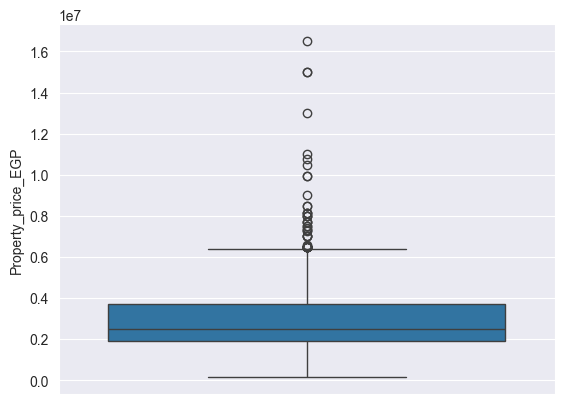

In [69]:
sns.boxplot(df['Property_price_EGP'])
plt.show()

In [70]:
miss_data = df.isnull().sum()
miss_data[miss_data > 0]

Property_price_EGP      230
Location_governorate    230
Bed_Rooms               230
Bath_Rooms              230
Home_Space_SQM          230
dtype: int64

In [71]:
display(df.head())
print(df.shape)

,Property_price_EGP,Location_governorate,Location_City,Bed_Rooms,Bath_Rooms,Home_Space_SQM,Furnished,Property_Type,Payment_Option,Delivery_Date
0,2700000.0,Cairo,New Cairo - El Tagamoa,3.0,2.0,200.0,No,Apartment,Cash,Ready To Move
1,2700000.0,Cairo,Tura,2.0,2.0,210.0,No,Apartment,Cash,Ready To Move
2,2100000.0,Cairo,Helwan,3.0,2.0,200.0,No,Apartment,Cash,Ready To Move
3,16500000.0,Cairo,Maadi,4.0,5.0,575.0,No,Apartment,Cash,Ready To Move
4,2750000.0,Cairo,New Cairo - El Tagamoa,3.0,2.0,200.0,No,Apartment,Cash,Ready To Move


(945, 10)


In [72]:
df['Property_price_EGP'].isna()

0      False
1      False
2      False
3      False
4      False
       ...  
940    False
941     True
942    False
943    False
944    False
Name: Property_price_EGP, Length: 945, dtype: bool

In [73]:
df.loc[941]

Property_price_EGP                NaN
Location_governorate              NaN
Location_City                 211 SQM
Bed_Rooms                         NaN
Bath_Rooms                        NaN
Home_Space_SQM                    NaN
Furnished                          No
Property_Type               Apartment
Payment_Option                   Cash
Delivery_Date           Ready To Move
Name: 941, dtype: object

In [74]:
df = df.dropna()

In [75]:
df.shape

(715, 10)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 715 entries, 0 to 944
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Property_price_EGP    715 non-null    float64
 1   Location_governorate  715 non-null    object 
 2   Location_City         715 non-null    object 
 3   Bed_Rooms             715 non-null    float64
 4   Bath_Rooms            715 non-null    float64
 5   Home_Space_SQM        715 non-null    float64
 6   Furnished             715 non-null    object 
 7   Property_Type         715 non-null    object 
 8   Payment_Option        715 non-null    object 
 9   Delivery_Date         715 non-null    object 
dtypes: float64(4), object(6)
memory usage: 61.4+ KB


In [77]:
X = df.drop('Property_price_EGP', axis=1)
y = df['Property_price_EGP']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Cairo'